In [2]:
import marimo as mo
import time
import timeit
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, ShuffleSplit, RepeatedKFold, cross_validate
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score
from skopt import BayesSearchCV
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import networkx as nx

In [3]:
data = fetch_california_housing()

In [4]:
california_housing_df = pd.DataFrame(data.data, columns=data.feature_names)
target = data.target_names[0]
california_housing_df[target] = data.target
chosen = pd.DataFrame(california_housing_df.iloc[-1]).T.reset_index(drop=True)
california_housing_df = california_housing_df[:-1]

In [5]:
california_housing_df.iloc[:5]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
chosen

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [7]:
X = california_housing_df[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']]
y = california_housing_df[target]

In [8]:
y.describe()

count    20639.000000
mean         2.068615
std          1.153955
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647500
max          5.000010
Name: MedHouseVal, dtype: float64

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [10]:
dt_shallow = DecisionTreeRegressor(max_depth=3, random_state=42)
dt_deep = DecisionTreeRegressor(max_depth=None, random_state=42)
dt_prune = DecisionTreeRegressor(max_depth=None, ccp_alpha=0.005, random_state=42)

In [11]:
def fitpred_single(dt, timing_count=1):
    fit_time = timeit.timeit(lambda: dt.fit(X_train, y_train), number=timing_count)
    print(f"Time to fit:\t\t{fit_time/timing_count}")

    pred_time = timeit.timeit(lambda: dt.predict(X_test), number=timing_count)
    print(f"Time to predict:\t{pred_time/timing_count}")
    dt_predict = dt.predict(X_test)

    print()

    print(f"MAE:\t{mean_absolute_error(y_test, dt_predict)}")
    print(f"MAPE:\t{mean_absolute_percentage_error(y_test, dt_predict)}")
    print(f"MSE:\t{mean_squared_error(y_test, dt_predict)}")
    print(f"RMSE:\t{root_mean_squared_error(y_test, dt_predict)}")
    print(f"R2:\t\t{r2_score(y_test, dt_predict)}")

    print()

    print(f"Chosen prediction:\t{float(dt.predict(chosen.drop(columns=target))[0])}")
    print(f"Chosen actual:\t\t{chosen[target].iloc[0]}")

    plt.figure(figsize=(12,4))
    plot_tree(dt, feature_names=X.columns, label='all', filled=True, impurity=True, proportion=True, rounded=True)
    plt.show()

Time to fit:		0.1644611000083387
Time to predict:	0.00297520007006824

MAE:	0.6049432188401798
MAPE:	0.3825341767408153
MSE:	0.6504945991553386
RMSE:	0.8065324538760599
R2:		0.5033467404974459

Chosen prediction:	1.1832063300027036
Chosen actual:		0.894


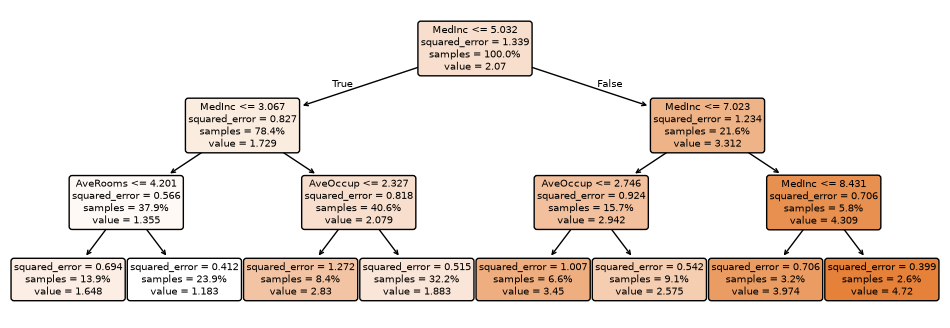

In [12]:
fitpred_single(dt_shallow)

Time to fit:		0.21874500019475818
Time to predict:	0.004454700043424964

MAE:	0.46988509302325576
MAPE:	0.2588006577352737
MSE:	0.5366482062172093
RMSE:	0.7325627660598164
R2:		0.5902685722985861

Chosen prediction:	0.819
Chosen actual:		0.894


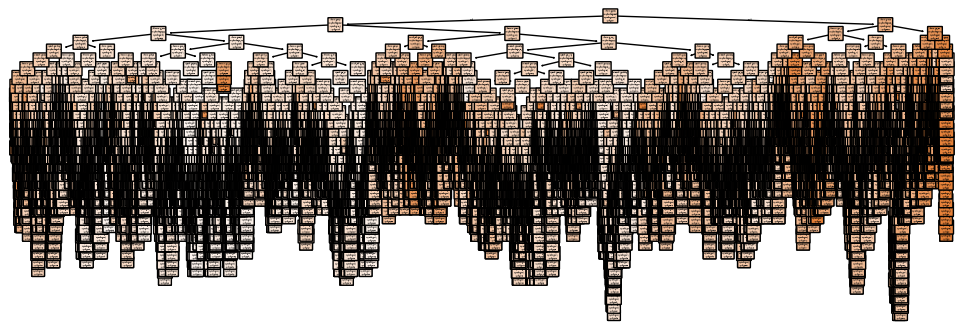

In [13]:
fitpred_single(dt_deep)

In [14]:
_leaf_indices = np.where((dt_deep.tree_.children_left == -1) & (dt_deep.tree_.children_right == -1))[0]
_unique_values = set()
for _leaf in _leaf_indices:
    _unique_values.add(dt_deep.tree_.value[_leaf][0, 0])
len(_unique_values)

3619

Time to fit:		1.607389499899
Time to predict:	0.002790499944239855

MAE:	0.5300021363613052
MAPE:	0.32980610004951305
MSE:	0.5180874104346161
RMSE:	0.719782891179428
R2:		0.604439757941566

Chosen prediction:	1.2797256474358996
Chosen actual:		0.894


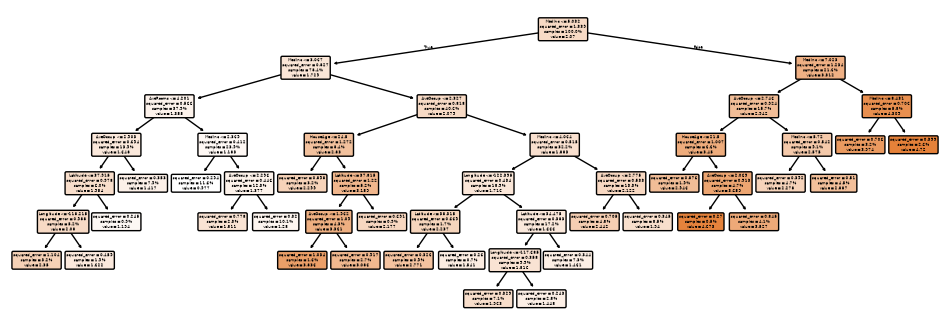

In [15]:
fitpred_single(dt_prune)

In [16]:
def fitpred_loop(dt, loops=1000):
    _start = time.time()

    maes = []
    mapes = []
    mses = []
    rmses = []
    r2s = []

    for _ in mo.status.progress_bar(range(loops)):
        X_train_loop, X_test_loop, y_train_loop, y_test_loop = train_test_split(X, y)
        dt.fit(X_train_loop, y_train_loop)
        _df_predict = dt.predict(X_test_loop)
        maes.append(mean_absolute_error(y_test_loop, _df_predict))
        mapes.append(mean_absolute_percentage_error(y_test_loop, _df_predict))
        mses.append(mean_squared_error(y_test_loop, _df_predict))
        rmses.append(root_mean_squared_error(y_test_loop, _df_predict))
        r2s.append(r2_score(y_test_loop, _df_predict))

    _end = time.time()
    _time = _end - _start

    return maes, mapes, mses, rmses, r2s, _time

In [17]:
def print_info(dt_suffix):
    dt_name = f"dt_{dt_suffix}"
    dt = globals()[dt_name]
    print(f"Depth:\t\t{dt.get_depth()}")
    print(f"Leaves:\t\t{dt.get_n_leaves()}")
    print(f"Nodes:\t\t{dt.tree_.node_count}")
    print(f"Params:\t\t{dt.get_params()}")
    print()
    maes = globals()[f"maes_{dt_suffix}"]
    print(f"MAE mean:\t{np.mean(maes):.3f}, std: {np.std(maes):.3f}")
    mapes = globals()[f"mapes_{dt_suffix}"]
    print(f"MAPE mean:\t{np.mean(mapes):.3f}, std: {np.std(mapes):.3f}")
    mses = globals()[f"mses_{dt_suffix}"]
    print(f"MSE mean:\t{np.mean(mses):.3f}, std: {np.std(mses):.3f}")
    rmses = globals()[f"rmses_{dt_suffix}"]
    print(f"RMSE mean:\t{np.mean(rmses):.3f}, std: {np.std(rmses):.3f}")
    r2s = globals()[f"r2s_{dt_suffix}"]
    print(f"R2 mean:\t{np.mean(r2s):.3f}, std: {np.std(r2s):.3f}")
    print()
    time = globals()[f"time_{dt_suffix}"]
    print(f"Time:\t\t{time:.1f}s")

In [18]:
maes_shallow, mapes_shallow, mses_shallow, rmses_shallow, r2s_shallow, time_shallow = fitpred_loop(dt_shallow)

In [19]:
print_info("shallow")

Depth:		3
Leaves:		8
Nodes:		15
Params:		{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 3, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

MAE mean:	0.598, std: 0.007
MAPE mean:	0.378, std: 0.007
MSE mean:	0.633, std: 0.015
RMSE mean:	0.796, std: 0.009
R2 mean:	0.525, std: 0.011

Time:		41.7s


In [20]:
maes_deep, mapes_deep, mses_deep, rmses_deep, r2s_deep, time_deep = fitpred_loop(dt_deep)

In [21]:
print_info("deep")

Depth:		34
Leaves:		14874
Nodes:		29747
Params:		{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

MAE mean:	0.463, std: 0.010
MAPE mean:	0.253, std: 0.008
MSE mean:	0.524, std: 0.022
RMSE mean:	0.724, std: 0.015
R2 mean:	0.606, std: 0.018

Time:		166.9s


In [22]:
def plot_branch_vertical(tree, X_sample, feature_names=None):
    plt.figure(figsize=(4, 12))
    tree_ = tree.tree_
    node_indicator = tree.decision_path([X_sample])
    node_index = node_indicator.indices

    if feature_names is None:
        feature_names = [f"feature_{i}" for i in range(tree_.n_features)]

    G = nx.DiGraph()
    for i, node_id in enumerate(node_index[:-1]):
        next_node_id = node_index[i+1]
        if tree_.children_left[node_id] == tree_.children_right[node_id]:
            label = f"Leaf {node_id}\nValue: {tree_.value[node_id][0]}"
        else:
            feature = feature_names[tree_.feature[node_id]]
            threshold = tree_.threshold[node_id]
            label = f"Node {node_id}\n{feature} <= {threshold:.2f}\nSample: {X_sample[tree_.feature[node_id]]:.2f}"
        G.add_node(node_id, label=label)
        G.add_edge(node_id, next_node_id)

    leaf_id = node_index[-1]
    label = f"Leaf {leaf_id}\nValue: {tree_.value[leaf_id][0]}"
    G.add_node(leaf_id, label=label)

    try:
        pos = nx.nx_pydot.graphviz_layout(G, prog='dot')
    except:
        print("graphviz_layout not available, falling back to spring_layout")
        pos = nx.spring_layout(G)

    labels = nx.get_node_attributes(G, 'label')
    nx.draw(G, pos, with_labels=False, arrows=True)
    nx.draw_networkx_labels(G, pos, labels)
    plt.show()

d:\LabD\Proyecto Odysseus\.venv\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


graphviz_layout not available, falling back to spring_layout


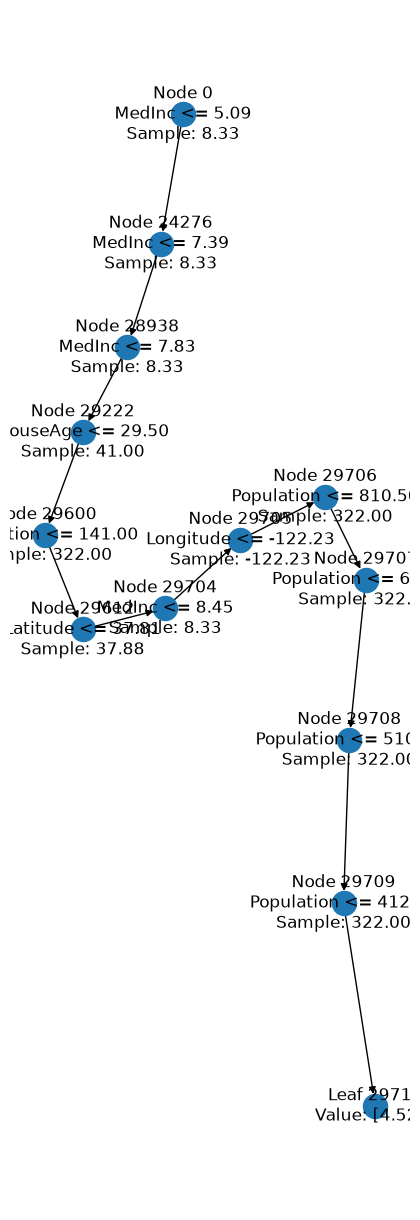

In [23]:
plot_branch_vertical(dt_deep, X.iloc[0].values, feature_names=X.columns)

In [24]:
maes_prune, mapes_prune, mses_prune, rmses_prune, r2s_prune, time_prune = fitpred_loop(dt_prune)

In [25]:
print_info("prune")

Depth:		6
Leaves:		20
Nodes:		39
Params:		{'ccp_alpha': 0.005, 'criterion': 'squared_error', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

MAE mean:	0.530, std: 0.013
MAPE mean:	0.324, std: 0.012
MSE mean:	0.520, std: 0.022
RMSE mean:	0.721, std: 0.015
R2 mean:	0.610, std: 0.016

Time:		1518.0s


In [26]:
_trace_maes_shallow = go.Box(y=maes_shallow, name='MAEs, Shallow Tree', marker_color='blue', width=0.6)
_trace_maes_deep = go.Box(y=maes_deep, name='MAEs, Deep Tree', marker_color='green', width=0.6)
_trace_maes_prune = go.Box(y=maes_prune, name='MAEs, Prune Tree', marker_color='red', width=0.6)
_trace_mapes_shallow = go.Box(y=mapes_shallow, name='MAPEs, Shallow Tree', marker_color='blue', width=0.6)
_trace_mapes_deep = go.Box(y=mapes_deep, name='MAPEs, Deep Tree', marker_color='green', width=0.6)
_trace_mapes_prune = go.Box(y=mapes_prune, name='MAPEs, Prune Tree', marker_color='red', width=0.6)
_trace_mses_shallow = go.Box(y=mses_shallow, name='MSEs, Shallow Tree', marker_color='blue', width=0.6)
_trace_mses_deep = go.Box(y=mses_deep, name='MSEs, Deep Tree', marker_color='green', width=0.6)
_trace_mses_prune = go.Box(y=mses_prune, name='MSEs, Prune Tree', marker_color='red', width=0.6)
_trace_rmses_shallow = go.Box(y=rmses_shallow, name='RMSEs, Shallow Tree', marker_color='blue', width=0.6)
_trace_rmses_deep = go.Box(y=rmses_deep, name='RMSEs, Deep Tree', marker_color='green', width=0.6)
_trace_rmses_prune = go.Box(y=rmses_prune, name='RMSEs, Prune Tree', marker_color='red', width=0.6)
_trace_r2s_shallow = go.Box(y=r2s_shallow, name='R2s, Shallow Tree', marker_color='blue', width=0.6)
_trace_r2s_deep = go.Box(y=r2s_deep, name='R2s, Deep Tree', marker_color='green', width=0.6)
_trace_r2s_prune = go.Box(y=r2s_prune, name='R2s, Prune Tree', marker_color='red', width=0.6)

_data = [_trace_maes_shallow, _trace_maes_deep, _trace_maes_prune, _trace_mapes_shallow, _trace_mapes_deep, _trace_mapes_prune, _trace_mses_shallow, _trace_mses_deep, _trace_mses_prune, _trace_rmses_shallow, _trace_rmses_deep, _trace_rmses_prune, _trace_r2s_shallow, _trace_r2s_deep, _trace_r2s_prune]

_layout = go.Layout(
    title='Comparison of Metrics for Decision Tree Variants',
    boxmode='group',
    xaxis=dict(tickangle=90),
)

go.Figure(data=_data, layout=_layout)

In [27]:
_maes_shallow_norm = np.array(maes_shallow) - np.mean(maes_shallow)
_maes_deep_norm = np.array(maes_deep) - np.mean(maes_deep)
_maes_prune_norm = np.array(maes_prune) - np.mean(maes_prune)

_trace_shallow = go.Box(y=_maes_shallow_norm, name='Shallow Tree', marker_color='blue', width=0.6)
_trace_deep = go.Box(y=_maes_deep_norm, name='Deep Tree', marker_color='green', width=0.6)
_trace_prune = go.Box(y=_maes_prune_norm, name='Prune Tree', marker_color='red', width=0.6)

_data = [_trace_shallow, _trace_deep, _trace_prune]

_layout = go.Layout(
    title='Normalised Comparison of MAEs for Decision Tree Variants',
    yaxis=dict(title='Mean Absolute Error (Normalised, Mean = 0)'),
    boxmode='group',
    # xaxis=dict(tickangle=90),
    width=400,
    height=400
)

go.Figure(data=_data, layout=_layout)

In [28]:
_trace_shallow = go.Histogram(x=maes_shallow, name='Shallow', opacity=0.5, marker_color='blue')
_trace_deep = go.Histogram(x=maes_deep, name='Deep', opacity=0.5, marker_color='green')
_trace_prune = go.Histogram(x=maes_prune, name='Pruned', opacity=0.5, marker_color='red')

_data = [_trace_shallow, _trace_deep, _trace_prune]

_layout = go.Layout(
    barmode='overlay',
    title='Overlapping Histogram of MAE Distributions',
    xaxis=dict(title='Mean Absolute Error'),
    yaxis=dict(title='Count'),
    width=800
)

go.Figure(data=_data, layout=_layout)

Time to fit:		0.04985910002142191
Time to predict:	0.0015216001775115728

MAE:	0.6025568611379545
MAPE:	0.3683206119384965
MSE:	0.6481392332424998
RMSE:	0.8050709491979572
R2:		0.50514506466409

Chosen prediction:	1.3767794814038752
Chosen actual:		0.894


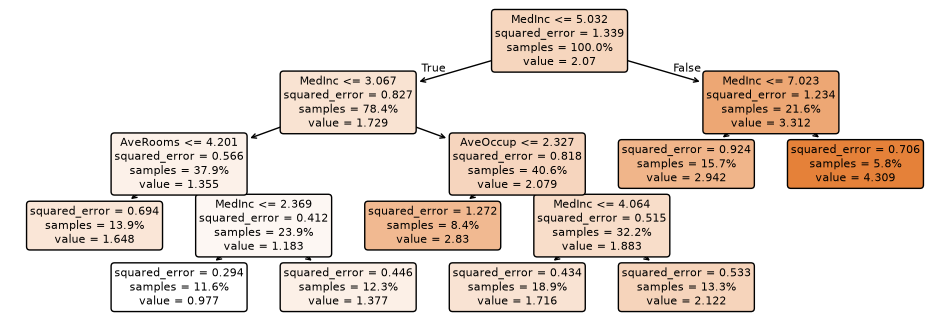

Depth:		5
Leaves:		9
Nodes:		17
Params:		{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 10, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 0.2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

MAE mean:	0.604, std: 0.012
MAPE mean:	0.366, std: 0.007
MSE mean:	0.651, std: 0.025
RMSE mean:	0.806, std: 0.015
R2 mean:	0.511, std: 0.018

Time:		44.1s


In [29]:
dt_split = DecisionTreeRegressor(max_depth=10, min_samples_split=0.2, random_state=42)
fitpred_single(dt_split)
maes_split, mapes_split, mses_split, rmses_split, r2s_split, time_split = fitpred_loop(dt_split)
print_info("split")

Time to fit:		0.12795970006845891
Time to predict:	0.0035251001827418804

MAE:	0.41714062416431613
MAPE:	0.24513453632261817
MSE:	0.3796527385195503
RMSE:	0.6161596696632702
R2:		0.7101347646703854

Chosen prediction:	0.9047719298245618
Chosen actual:		0.894


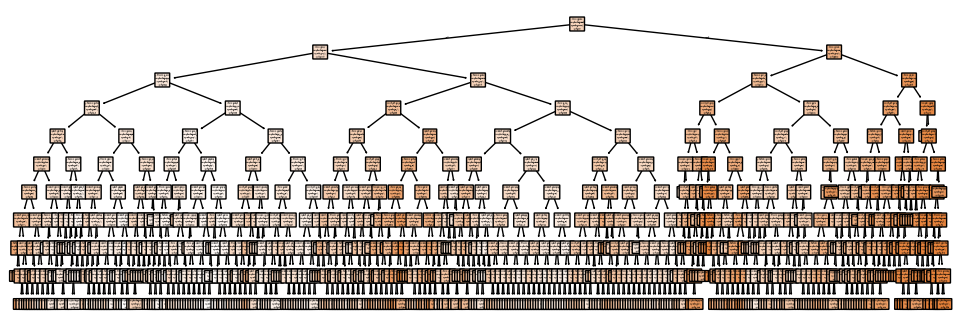

Depth:		10
Leaves:		477
Nodes:		953
Params:		{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 10, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

MAE mean:	0.417, std: 0.010
MAPE mean:	0.236, std: 0.008
MSE mean:	0.382, std: 0.017
RMSE mean:	0.618, std: 0.013
R2 mean:	0.713, std: 0.013

Time:		99.6s


In [30]:
dt_leaf = DecisionTreeRegressor(max_depth=10, min_samples_leaf=10, random_state=42)
fitpred_single(dt_leaf)
maes_leaf, mapes_leaf, mses_leaf, rmses_leaf, r2s_leaf, time_leaf = fitpred_loop(dt_leaf)
print_info("leaf")

Time to fit:		0.11343679996207356
Time to predict:	0.0027660999912768602

MAE:	0.4485407547115084
MAPE:	0.26985061623727186
MSE:	0.41302423560315277
RMSE:	0.6426696162128351
R2:		0.6846555941706265

Chosen prediction:	1.138620506756758
Chosen actual:		0.894


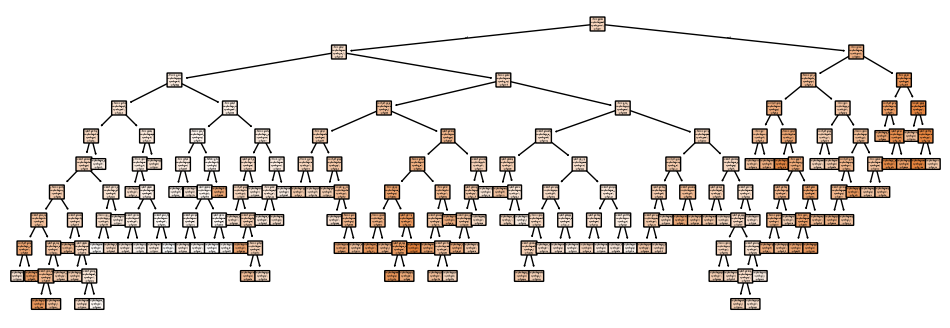

Depth:		10
Leaves:		100
Nodes:		199
Params:		{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 10, 'max_features': None, 'max_leaf_nodes': 100, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

MAE mean:	0.450, std: 0.011
MAPE mean:	0.265, std: 0.009
MSE mean:	0.415, std: 0.018
RMSE mean:	0.644, std: 0.014
R2 mean:	0.688, std: 0.013

Time:		86.7s


In [31]:
dt_max = DecisionTreeRegressor(max_depth=10, max_leaf_nodes=100, random_state=42)
fitpred_single(dt_max)
maes_max, mapes_max, mses_max, rmses_max, r2s_max, time_max = fitpred_loop(dt_max)
print_info("max")

In [32]:
_tree = dt_max.tree_
_is_leaf = (_tree.children_left == -1) & (_tree.children_right == -1)
_leaf_samples = _tree.n_node_samples[_is_leaf]
_total_samples = _tree.n_node_samples[0]  # Root node has all samples
_percent_per_leaf = _leaf_samples / _total_samples * 100
_leaf_indices = np.where(_is_leaf)[0]
for _idx, _s, _perc in zip(_leaf_indices, _leaf_samples, _percent_per_leaf):
    print(f"Leaf node {_idx}: {_s} samples ({_perc:.2f}%)")

Leaf node 30: 128 samples (0.83%)
Leaf node 41: 234 samples (1.51%)
Leaf node 55: 83 samples (0.54%)
Leaf node 59: 48 samples (0.31%)
Leaf node 64: 162 samples (1.05%)
Leaf node 65: 65 samples (0.42%)
Leaf node 72: 399 samples (2.58%)
Leaf node 74: 228 samples (1.47%)
Leaf node 76: 527 samples (3.40%)
Leaf node 80: 262 samples (1.69%)
Leaf node 82: 244 samples (1.58%)
Leaf node 85: 157 samples (1.01%)
Leaf node 88: 444 samples (2.87%)
Leaf node 90: 238 samples (1.54%)
Leaf node 93: 97 samples (0.63%)
Leaf node 94: 72 samples (0.47%)
Leaf node 95: 247 samples (1.60%)
Leaf node 97: 148 samples (0.96%)
Leaf node 98: 91 samples (0.59%)
Leaf node 100: 436 samples (2.82%)
Leaf node 101: 115 samples (0.74%)
Leaf node 102: 41 samples (0.26%)
Leaf node 104: 61 samples (0.39%)
Leaf node 106: 135 samples (0.87%)
Leaf node 108: 522 samples (3.37%)
Leaf node 109: 129 samples (0.83%)
Leaf node 110: 123 samples (0.79%)
Leaf node 111: 125 samples (0.81%)
Leaf node 112: 138 samples (0.89%)
Leaf node 11

In [35]:
from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Definición rigurosa del espacio bayesiano
search_space = {
    'max_depth': Integer(3, 22),
    'min_samples_split': Integer(5, 80),
    'min_samples_leaf': Integer(2, 50),
    'max_features': Real(0.4, 1.0, prior='uniform'),
    'criterion': Categorical(['squared_error', 'poisson']),
    # Poda de complejidad en escala log-uniform para evitar el colapso del árbol
    'ccp_alpha': Real(1e-5, 0.02, prior='log-uniform'),
}

# 2. Configuración del optimizador bayesiano
opt = BayesSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    search_spaces=search_space,
    n_iter=40,            # 40 iteraciones x 5 folds = 200 fits (convergencia óptima < 30 seg)
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_absolute_error',
    verbose=1,
    random_state=42
)

# 3. Ajuste sobre conjunto de entrenamiento
opt.fit(X_train, y_train)

# 4. Evaluación de resultados
best_tree = opt.best_estimator_
y_pred_test = best_tree.predict(X_test)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

print("\n" + "=" * 50)
print(f"Mejores Hiperparámetros:\n{dict(opt.best_params_)}")
print(f"Mejor MAE (CV 5-Fold): {-opt.best_score_:.4f} ($100k)")
print(f"MAE en Test (Out-of-Sample): {test_mae:.4f} ($100k)")
print(f"R² en Test: {test_r2:.4f}")
print(f"Profundidad real obtenida: {best_tree.get_depth()}")
print(f"Número total de hojas: {best_tree.get_n_leaves()}")
print("=" * 50)


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [36]:
# dt_bscv = opt.best_estimator_

dt_bscv = DecisionTreeRegressor(ccp_alpha=0.0, criterion='squared_error', max_depth=100, max_features=0.9193546958301854, min_samples_leaf=15, min_samples_split=24)
dt_bscv.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",100
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",24
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",0.9193546958301854
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=Non

In [37]:
dt_bscv.predict(chosen.drop(columns='MedHouseVal'))

array([0.74595])

In [38]:
maes_bscv, mapes_bscv, mses_bscv, rmses_bscv, r2s_bscv, time_bscv = fitpred_loop(dt_bscv)

In [39]:
print_info("bscv")

Depth:		18
Leaves:		803
Nodes:		1605
Params:		{'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': 100, 'max_features': 0.9193546958301854, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 15, 'min_samples_split': 24, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}

MAE mean:	0.405, std: 0.010
MAPE mean:	0.225, std: 0.008
MSE mean:	0.368, std: 0.016
RMSE mean:	0.606, std: 0.014
R2 mean:	0.724, std: 0.012

Time:		99.5s


In [40]:
_trace_maes_shallow = go.Box(y=maes_shallow, name='MAEs, Shallow Tree', marker_color='blue', width=0.6)
_trace_maes_deep = go.Box(y=maes_deep, name='MAEs, Deep Tree', marker_color='green', width=0.6)
_trace_maes_prune = go.Box(y=maes_prune, name='MAEs, Prune Tree', marker_color='red', width=0.6)
_trace_maes_bscv = go.Box(y=maes_bscv, name='MAEs, Bayes Tree', marker_color='black', width=0.6)
_trace_mapes_shallow = go.Box(y=mapes_shallow, name='MAPEs, Shallow Tree', marker_color='blue', width=0.6)
_trace_mapes_deep = go.Box(y=mapes_deep, name='MAPEs, Deep Tree', marker_color='green', width=0.6)
_trace_mapes_prune = go.Box(y=mapes_prune, name='MAPEs, Prune Tree', marker_color='red', width=0.6)
_trace_mapes_bscv = go.Box(y=mapes_bscv, name='MAPEs, Bayes Tree', marker_color='black', width=0.6)
_trace_mses_shallow = go.Box(y=mses_shallow, name='MSEs, Shallow Tree', marker_color='blue', width=0.6)
_trace_mses_deep = go.Box(y=mses_deep, name='MSEs, Deep Tree', marker_color='green', width=0.6)
_trace_mses_prune = go.Box(y=mses_prune, name='MSEs, Prune Tree', marker_color='red', width=0.6)
_trace_mses_bscv = go.Box(y=mses_bscv, name='MSEs, Bayes Tree', marker_color='black', width=0.6)
_trace_rmses_shallow = go.Box(y=rmses_shallow, name='RMSEs, Shallow Tree', marker_color='blue', width=0.6)
_trace_rmses_deep = go.Box(y=rmses_deep, name='RMSEs, Deep Tree', marker_color='green', width=0.6)
_trace_rmses_prune = go.Box(y=rmses_prune, name='RMSEs, Prune Tree', marker_color='red', width=0.6)
_trace_rmses_bscv = go.Box(y=rmses_bscv, name='RMSEs, Bayes Tree', marker_color='black', width=0.6)
_trace_r2s_shallow = go.Box(y=r2s_shallow, name='R2s, Shallow Tree', marker_color='blue', width=0.6)
_trace_r2s_deep = go.Box(y=r2s_deep, name='R2s, Deep Tree', marker_color='green', width=0.6)
_trace_r2s_prune = go.Box(y=r2s_prune, name='R2s, Prune Tree', marker_color='red', width=0.6)
_trace_r2s_bscv = go.Box(y=r2s_bscv, name='R2s, Bayes Tree', marker_color='black', width=0.6)

_data = [
    _trace_maes_shallow, _trace_maes_deep, _trace_maes_prune, _trace_maes_bscv, 
    _trace_mapes_shallow, _trace_mapes_deep, _trace_mapes_prune, _trace_mapes_bscv, 
    _trace_mses_shallow, _trace_mses_deep, _trace_mses_prune, _trace_mses_bscv, 
    _trace_rmses_shallow, _trace_rmses_deep, _trace_rmses_prune, _trace_rmses_bscv, 
    _trace_r2s_shallow, _trace_r2s_deep, _trace_r2s_prune, _trace_r2s_bscv
]

_layout = go.Layout(
    title='Comparison of Errors for Decision Tree Variants',
    yaxis=dict(title='Error'),
    boxmode='group',
    xaxis=dict(tickangle=90),
)

go.Figure(data=_data, layout=_layout)

In [41]:
scoring = ['neg_mean_absolute_error', 'neg_mean_absolute_percentage_error', 'neg_mean_squared_error', 'r2']

In [42]:
_cv = ShuffleSplit(n_splits=1000, test_size=0.2, random_state=42)
sscv_results = cross_validate(dt_bscv, X, y, cv=_cv, scoring=scoring, return_train_score=False)
sscv_results

{'fit_time': array([0.1394124 , 0.12797475, 0.19521141, 0.12133431, 0.10826898,
        0.1157639 , 0.11770606, 0.12523508, 0.11051917, 0.10221291,
        0.09928632, 0.10101938, 0.09960532, 0.10266304, 0.10840106,
        0.11013865, 0.11837983, 0.09990907, 0.0999229 , 0.09483814,
        0.10939455, 0.11180639, 0.10611916, 0.10181212, 0.10819149,
        0.09637237, 0.10295939, 0.09816766, 0.0937531 , 0.0936954 ,
        0.09483361, 0.09694839, 0.09548926, 0.10078716, 0.09469104,
        0.10138369, 0.11384654, 0.09768891, 0.09752202, 0.09760857,
        0.09592319, 0.10015488, 0.09743786, 0.0949955 , 0.10025406,
        0.09927392, 0.09608006, 0.1423595 , 0.09398985, 0.09753871,
        0.09276748, 0.09673977, 0.09530139, 0.09608817, 0.09546185,
        0.09890699, 0.09534431, 0.09431815, 0.09584713, 0.09640074,
        0.09582329, 0.09771562, 0.0977273 , 0.09637475, 0.10033464,
        0.09570694, 0.10686398, 0.09545517, 0.09618855, 0.09833312,
        0.09936571, 0.09396648, 0.09

In [43]:
_cv = RepeatedKFold(n_splits=5, n_repeats=200, random_state=42)  # 5*200=1000 splits
rkf_results = cross_validate(dt_bscv, X, y, cv=_cv, scoring=scoring, return_train_score=False)
rkf_results

{'fit_time': array([0.1734817 , 0.16199207, 0.11924291, 0.10079741, 0.11921144,
        0.10826182, 0.09692574, 0.09657025, 0.09569979, 0.09465671,
        0.0956614 , 0.09532905, 0.09368849, 0.09634757, 0.09884834,
        0.09878325, 0.09604335, 0.09758806, 0.09721637, 0.0951643 ,
        0.09693646, 0.09486318, 0.09473157, 0.09446955, 0.10172153,
        0.09616613, 0.09693694, 0.09632063, 0.09699321, 0.09900641,
        0.0936625 , 0.0919292 , 0.0947094 , 0.09901762, 0.09503579,
        0.09973025, 0.09605527, 0.09807658, 0.09608388, 0.10083127,
        0.09382105, 0.09469271, 0.09517598, 0.09662366, 0.09672785,
        0.09705687, 0.09404898, 0.1081357 , 0.09244847, 0.09508133,
        0.09477091, 0.10319805, 0.10349703, 0.09402275, 0.091712  ,
        0.09655499, 0.09478474, 0.09587336, 0.09847546, 0.09720707,
        0.09326315, 0.09395671, 0.09070778, 0.09446597, 0.09414482,
        0.09595537, 0.09595847, 0.09420872, 0.09483719, 0.09498882,
        0.09647298, 0.09486771, 0.09